In [396]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from xgboost import  XGBRegressor


In [397]:
df=pd.read_csv('house.csv')
df.head()

,Unnamed: 0,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [398]:
df = df.drop(columns=['Address', 'Zip', 'Unnamed: 0'])

In [399]:
df.isnull().sum()

Price    4
Area     0
Room     0
Lon      0
Lat      0
dtype: int64

In [400]:
df.dropna(inplace=True)

In [401]:
df.duplicated().sum()

np.int64(3)

In [402]:
df.drop_duplicates(inplace=True)

In [403]:
df.describe()

,Price,Area,Room,Lon,Lat
count,9.170000e+02,917.000000,917.000000,917.000000,917.000000
mean,6.231095e+05,95.708833,3.565976,4.888509,52.363351
std,5.395628e+05,56.904072,1.572574,0.052897,0.024043
min,1.750000e+05,21.000000,1.000000,4.644819,52.291519
25%,3.500000e+05,60.000000,3.000000,4.855835,52.352165
50%,4.690000e+05,83.000000,3.000000,4.886718,52.364636
75%,7.000000e+05,113.000000,4.000000,4.922210,52.377550
max,5.950000e+06,623.000000,14.000000,5.029122,52.423805


In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 917 entries, 0 to 923
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   917 non-null    float64
 1   Area    917 non-null    int64  
 2   Room    917 non-null    int64  
 3   Lon     917 non-null    float64
 4   Lat     917 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 43.0 KB


<Axes: >

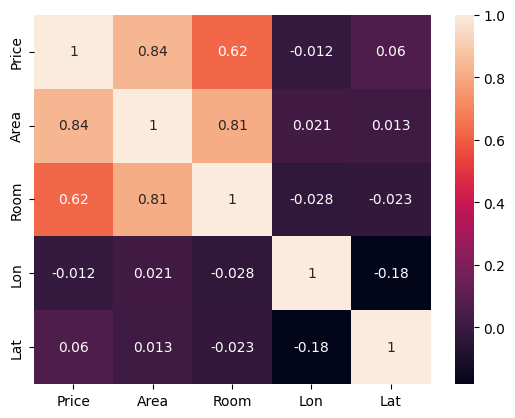

In [405]:
sns.heatmap(df.corr(),annot=True)

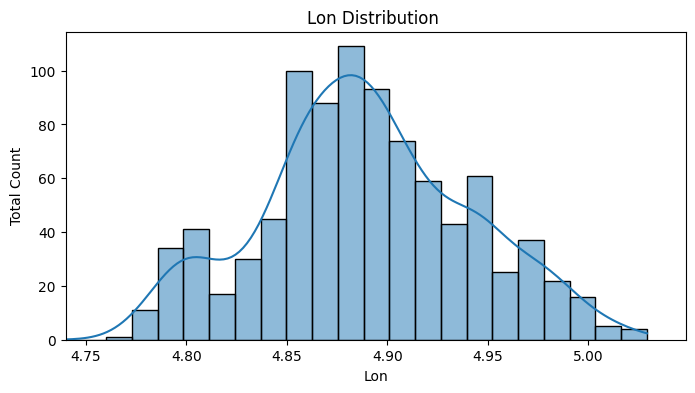

In [406]:
plt.figure(figsize=(8, 4))
sns.histplot(data=x, x='Lon', kde=True, multiple='layer',bins=30)
plt.xlim(4.74)
plt.title('Lon Distribution ')
plt.xlabel('Lon')
plt.ylabel('Total Count')
plt.show()


In [407]:
x=df[['Area','Room','Lon','Lat']]
y=df['Price']

In [408]:
x_test ,x_train ,y_test ,y_train =train_test_split(x,y,random_state=42,test_size=0.2)

In [409]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [410]:
model=XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,min_child_weight=3,subsample=0.8,
                           colsample_bytree=0.8,gamma=0,reg_alpha=0,reg_lambda=1,random_state=42)


In [411]:
model.fit(x_train, y_train_log)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [412]:
y_pred_log = model.predict(x_test)


In [413]:
y_pre = np.expm1(y_pred_log)

In [414]:
print("MAE:", mean_absolute_error(y_test, y_pre))
print("R²:", r2_score(y_test, y_pre))

MAE: 122568.96625596863
R²: 0.7539626649066922


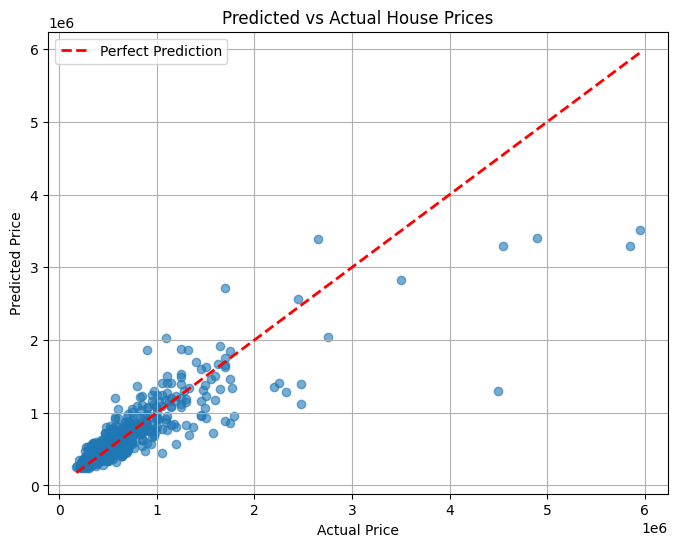

In [416]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pre, alpha=0.6, color='tab:blue')

min_val = min(y_test.min(), y_pre.min())
max_val = max(y_test.max(), y_pre.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         linewidth=2,
         label='Perfect Prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.grid(True)

plt.show()

Your model's R² score of about 0.74 means it can explain roughly 74% of the differences in house prices using the features you gave it. In plain English, that means the predictions are fairly close to the real prices most of the time. About 26% of the price differences are still not explained, so the model is helpful but not perfect. Think of it as the model getting the general pattern right, while still missing some of the details.

<--------------------------------------------------------------------------------------------------------------------------------------------->